In [48]:
# 01 Data Exploration: Financial PhraseBank

In [49]:
'''Problem Statement: Given a sentence from English-language financial news,
classify its sentiment (from an investor's perspective) as
negative, neutral or positive.'''

"Problem Statement: Given a sentence from English-language financial news,\nclassify its sentiment (from an investor's perspective) as\nnegative, neutral or positive."

In [ ]:
''' Dataset: Financial PhraseBank (Malo et al., 2014) — `sentences_50agree`
config (≥50% annotator agreement, 4846 sentences). Labeled by 16 annotators
with finance/business backgrounds (3 researchers + 13 Aalto University
master's students in finance, accounting, economics), explicitly instructed
to judge sentiment from an investor's viewpoint. Sentences with no
investor-relevant sentiment are labeled neutral by design.

License: CC BY-NC-SA 3.0 — non-commercial use with attribution.
Citation: Malo, P., Sinha, A., Korhonen, P., Wallenius, J., & Takala, P.
(2014). Good debt or bad debt: Detecting semantic orientations in economic
texts. Journal of the Association for Information Science and Technology, 65(4)'''

In [50]:
'''Goals of this notebook: understand the data, spot problems (duplicates,
conflicting labels, imbalance), and choose a sensible max sequence length.'''

'Goals of this notebook: understand the data, spot problems (duplicates,\nconflicting labels, imbalance), and choose a sensible max sequence length.'

In [51]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer
from collections import Counter
import re

In [52]:
RESULTS = Path("results")
RESULTS.mkdir(exist_ok=True)

In [53]:
# Choosing 50agree = all 4846 sentences (>=50% annotator agreement).
CONFIG = "sentences_50agree"
LABELS = {0: "negative", 1: "neutral", 2: "positive"}  # from the dataset card

### 1.Loading the data

In [54]:
# Dataset downloaded from https://huggingface.co/datasets/takala/financial_phrasebank/tree/main

# The original files use latin-1 encoding, not utf-8 — utf-8 will error or garble characters
rows = []
DATA_PATH = r"../FinancialPhraseBank-v1.0/Sentences_50Agree.txt"

with open(DATA_PATH, "r", encoding="latin-1") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        sentence, label = line.rsplit("@", 1)  # split on the LAST '@' in case sentence has one
        rows.append((sentence, label))

df = pd.DataFrame(rows, columns=["sentence", "label_name"])
print(df.shape)
print(df.head())
print(df["label_name"].value_counts())


(4846, 2)
                                                                                                                                                                                                  sentence  \
0                                                                          According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .   
1           Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies working in computer technologies and telecommunications , the statement said .   
2  The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers ...   
3  With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and theref

### 2.Basic Quality Check

In [55]:
print("Missing values:\n", df.isna().sum(), "\n")
print("Number of classes:", df["label_name"].nunique())
 
dup_count = df.duplicated(subset="sentence").sum()
print("Duplicate sentences:", dup_count)
 
# Same sentence with different labels = label_name noise
conflicts = df.groupby("sentence")["label_name"].nunique()
print("Sentences with conflicting labels:", (conflicts > 1).sum())

Missing values:
 sentence      0
label_name    0
dtype: int64 

Number of classes: 3
Duplicate sentences: 8
Sentences with conflicting labels: 2


In [56]:
'''Duplicates matter for data leakage: if the same sentence lands in both
# train and test, the test score is inflated. We will deduplicate before splitting.'''

'Duplicates matter for data leakage: if the same sentence lands in both\n# train and test, the test score is inflated. We will deduplicate before splitting.'

### 3. Class Distribution

label_name
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64
label_name
neutral     0.594
positive    0.281
negative    0.125
Name: count, dtype: float64


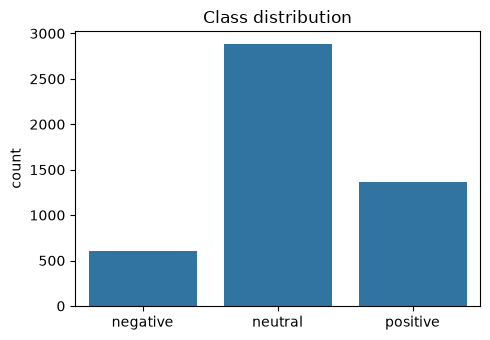

In [57]:
counts = df["label_name"].value_counts()
print(counts)
print((counts / len(df)).round(3))
 
plt.figure(figsize=(5, 3.5))
sns.countplot(data=df, x="label_name", order=["negative", "neutral", "positive"])
plt.title("Class distribution")
plt.xlabel("")
plt.tight_layout()
plt.savefig(RESULTS / "class_distribution.png", dpi=150)
plt.show()

### 4. Sentence Length (Words and Tokens)

count    4846.000000
mean       23.101114
std         9.958474
min         2.000000
25%        16.000000
50%        21.000000
75%        29.000000
max        81.000000
Name: n_words, dtype: float64
count    4846.000000
mean       30.605654
std        13.609347
min         4.000000
25%        21.000000
50%        28.000000
75%        38.000000
max       150.000000
Name: n_tokens, dtype: float64
95th percentile token length: 57
99th percentile token length: 68
100th percentile token length: 150


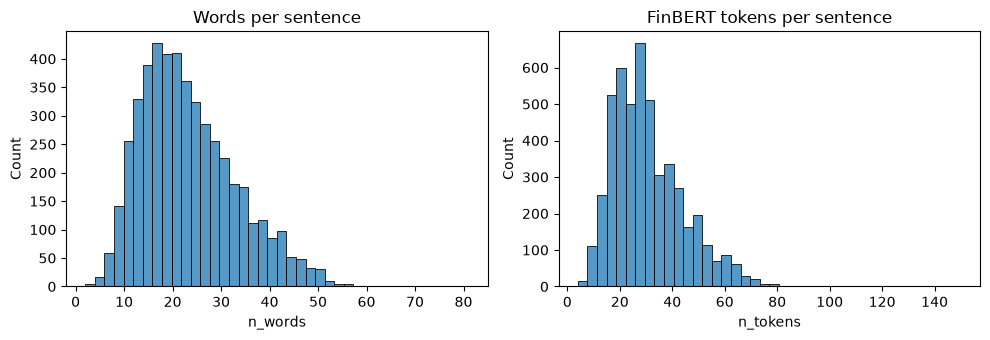

In [ ]:
df["n_words"] = df["sentence"].str.split().str.len()
print(df["n_words"].describe())
 
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
df["n_tokens"] = df["sentence"].apply(lambda s: len(tokenizer(s)["input_ids"]))
# The above code loads whatever tokenizer FinBERT was actually trained with — 
# which is WordPiece, the same subword tokenization BERT uses.


print(df["n_tokens"].describe())
for q in (0.95, 0.99, 1.0):
    print(f"{int(q*100)}th percentile token length:", int(df["n_tokens"].quantile(q)))
 
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
sns.histplot(df["n_words"], bins=40, ax=ax[0])
ax[0].set_title("Words per sentence")
sns.histplot(df["n_tokens"], bins=40, ax=ax[1])
ax[1].set_title("FinBERT tokens per sentence")
plt.tight_layout()
plt.savefig(RESULTS / "length_distribution.png", dpi=150)
plt.show()

### 5. Examples from each class

In [59]:
pd.set_option("display.max_colwidth", 200)
for name in ["negative", "neutral", "positive"]:
    print(f"\n=== {name.upper()} ===")
    for s in df[df["label_name"] == name]["sentence"].sample(4, random_state=42):
        print("-", s)


=== NEGATIVE ===
- The company decided at the end of 2008 to temporarily shut down its ammonia plant in Billingham and extend the maintenance period at its Ince facility .
- down to EUR5 .9 m H1 '09 3 August 2009 - Finnish media group Ilkka-Yhtyma Oyj ( HEL : ILK2S ) said today its net profit fell 45 % on the year to EUR5 .9 m in the first half of 2009 .
- The steelmaker said that the drop in profit was explained by the continuing economic uncertainty , mixed with the current drought in bank lending , resulting in a decline in demand for its products as customers find it increasingly difficult to fund operations .
- Finland-based Stockmann Group has closed seven franchising sports stores Nike in Russia .

=== NEUTRAL ===
- The center offers a comprehensive range of device design services spanning from electronics , mechanics and software design to a full range of testing laboratory services .
- AffectoGenimap builds highly customised IT solutions for its customers in Finland and the B

### 6.Vocabulary and word-frequency check per class

In [60]:

# A standard English stopword list, via scikit-learn (already in your requirements.txt)
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

EXTRA_STOPWORDS = {"eur", "mn", "said", "company", "ltd", "corp", "oyj"}
STOPWORDS = ENGLISH_STOP_WORDS.union(EXTRA_STOPWORDS)

def word_counts(sentences):
    text = " ".join(sentences).lower()
    words = re.findall(r"\b[a-z]{3,}\b", text)
    words = [w for w in words if w not in STOPWORDS]
    return Counter(words)

MIN_COUNT = 5  # ignore rare words - a word appearing twice can look "distinctive" by fluke

counts_by_class = {
    name: word_counts(df[df["label_name"] == name]["sentence"])
    for name in ["positive", "negative", "neutral"]
}
total_counts = sum(counts_by_class.values(), Counter())

for name in ["positive", "negative", "neutral"]:
    this_class = counts_by_class[name]
    other_total = total_counts - this_class

    scores = {}
    for word, count in this_class.items():
        if count < MIN_COUNT:
            continue
        other_count = other_total.get(word, 0)
        # +1 smoothing avoids division by zero for words absent elsewhere
        scores[word] = count / (other_count + 1)

    top = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:15]
    print(f"\n=== Most distinctive words for {name.upper()} ===")
    for word, score in top:
        print(f"  {word:15s} count={this_class[word]:4d}  ratio={score:.1f}")


=== Most distinctive words for POSITIVE ===
  improved        count=  21  ratio=21.0
  narrowed        count=  17  ratio=17.0
  grew            count=  33  ratio=16.5
  won             count=  32  ratio=10.7
  rose            count=  94  ratio=10.4
  lithuanian      count=   8  ratio=8.0
  awarded         count=  32  ratio=8.0
  expands         count=   7  ratio=7.0
  positive        count=  25  ratio=6.2
  favourable      count=   6  ratio=6.0
  escalators      count=   6  ratio=6.0
  stronger        count=   6  ratio=6.0
  consensus       count=   6  ratio=6.0
  respectively    count=  21  ratio=5.2
  doubled         count=   5  ratio=5.0

=== Most distinctive words for NEGATIVE ===
  warning         count=  11  ratio=11.0
  laid            count=  10  ratio=10.0
  slipped         count=  10  ratio=10.0
  drop            count=   7  ratio=7.0
  temporarily     count=  13  ratio=6.5
  decreased       count=  68  ratio=5.7
  fell            count=  46  ratio=4.6
  dropped         coun

### 7.Numbers/financial figures presence

In [61]:
# Flag sentences that contain at least one digit (0-9)
df["has_number"] = df["sentence"].str.contains(r"\d", regex=True)

# % of sentences with a number, per sentiment class - checks if one class leans more "numeric"
print(df.groupby("label_name")["has_number"].mean())

label_name
negative    0.753311
neutral     0.466481
positive    0.576669
Name: has_number, dtype: float64


### 8. Negation word presence


In [62]:
NEGATIONS = r"\b(not|no|never|neither|without|fails?|failing|failed)\b"
# Flag sentences containing common negation words (not, no, never, etc.)
df["has_negation"] = df["sentence"].str.contains(NEGATIONS, case=False, regex=True)

# % of sentences with negation, per sentiment class - negation is a classic source of sentiment errors
print(df.groupby("label_name")["has_negation"].mean())

label_name
negative    0.024834
neutral     0.050712
positive    0.005136
Name: has_negation, dtype: float64


C:\Users\utkar\AppData\Local\Temp\ipykernel_13720\1049116433.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["has_negation"] = df["sentence"].str.contains(NEGATIONS, case=False, regex=True)


### 9. Company/entity name check

In [63]:

# Rough heuristic: sequences of 1-3 capitalized words (crude company/entity name detector)
df["entity_matches"] = df["sentence"].apply(lambda s: re.findall(r"\b([A-Z][a-zA-Z]+(?:\s[A-Z][a-zA-Z]+){0,2})\b", s))

# Count how many unique "entity-like" names appear across the whole dataset
from collections import Counter
all_entities = [e for matches in df["entity_matches"] for e in matches]
print("Unique entity-like mentions:", len(set(all_entities)))
print(Counter(all_entities).most_common(15))

Unique entity-like mentions: 4943
[('The', 1169), ('EUR', 919), ('Finnish', 386), ('Finland', 296), ('In', 153), ('Operating', 120), ('Nokia', 90), ('According', 84), ('September', 84), ('It', 83), ('January', 82), ('Russia', 79), ('Helsinki', 77), ('We', 72), ('USD', 71)]


### 10. Notes

In [ ]:
'''
First Finding is about label names
1) label_name
neutral     2879
positive    1363
negative     604

Second Finding is about Missing values, duplicate sentences, conflicting labels
2) Missing values:
sentence      0
label_name    0

Number of classes: 3
Duplicate sentences: 8
Sentences with conflicting labels: 2

Third Finding is about % of each label present
3) %
neutral     0.594
positive    0.281
negative    0.125

4) Token length by percentile (Tokenizer used is WordPiece)

95th percentile token length: 57
99th percentile token length: 68
100th percentile token length: 150

5) Distinctive words (frequency-ratio method)
=== Most distinctive words for POSITIVE ===
  improved        count=  21  ratio=21.0
  narrowed        count=  17  ratio=17.0
  grew            count=  33  ratio=16.5
  won             count=  32  ratio=10.7
  rose            count=  94  ratio=10.4
  lithuanian      count=   8  ratio=8.0
  awarded         count=  32  ratio=8.0
  expands         count=   7  ratio=7.0
  positive        count=  25  ratio=6.2
  favourable      count=   6  ratio=6.0
  escalators      count=   6  ratio=6.0
  stronger        count=   6  ratio=6.0
  consensus       count=   6  ratio=6.0
  respectively    count=  21  ratio=5.2
  doubled         count=   5  ratio=5.0

=== Most distinctive words for NEGATIVE ===
  warning         count=  11  ratio=11.0
  laid            count=  10  ratio=10.0
  slipped         count=  10  ratio=10.0
  drop            count=   7  ratio=7.0
  temporarily     count=  13  ratio=6.5
  decreased       count=  68  ratio=5.7
  fell            count=  46  ratio=4.6
  dropped         count=  13  ratio=4.3
  strike          count=   6  ratio=3.0
  lay             count=  23  ratio=2.6
  redundant       count=   5  ratio=2.5
  lower           count=  29  ratio=2.4
  layoffs         count=   6  ratio=2.0
  workers         count=  10  ratio=2.0
  fall            count=  10  ratio=2.0

=== Most distinctive words for NEUTRAL ===
  www             count=  29  ratio=29.0
  square          count=  25  ratio=25.0
  details         count=  24  ratio=24.0
  disclosed       count=  24  ratio=24.0
  espoo           count=  20  ratio=20.0
  subscribed      count=  19  ratio=19.0
  alexandria      count=  18  ratio=18.0
  headquartered   count=  32  ratio=16.0
  includes        count=  53  ratio=13.2
  special         count=  13  ratio=13.0
  establish       count=  13  ratio=13.0
  capman          count=  36  ratio=12.0
  rights          count=  48  ratio=12.0
  street          count=  12  ratio=12.0
  analysis        count=  24  ratio=12.0

'''

'\nFirst Finding is about label names\n1) label_name\nneutral     2879\npositive    1363\nnegative     604\n\nSecond Finding is about Missing values, duplicate sentences, conflicting labels\n2) Missing values:\nsentence      0\nlabel_name    0\n\nNumber of classes: 3\nDuplicate sentences: 8\nSentences with conflicting labels: 2\n\nThird Finding is about % of each label present\n3) %\nneutral     0.594\npositive    0.281\nnegative    0.125\n\n4) Token length by percentile (Tokenizer used is WordPiece)\n\n95th percentile token length: 57\n99th percentile token length: 68\n100th percentile token length: 150\n\n5) Frequent Words (TF-IDF method)\n=== Most distinctive words for POSITIVE ===\n  improved        count=  21  ratio=21.0\n  narrowed        count=  17  ratio=17.0\n  grew            count=  33  ratio=16.5\n  won             count=  32  ratio=10.7\n  rose            count=  94  ratio=10.4\n  lithuanian      count=   8  ratio=8.0\n  awarded         count=  32  ratio=8.0\n  expands    